# Film Endüstrisi Finansal Performans ve Tür Analizi Raporu

## 1. Veri Seti Tanıtımı
Bu çalışma kapsamında incelenen veri seti, film endüstrisindeki yapımların finansal başarılarını, bütçelerini ve demografik hedef kitlelerini analiz etmek amacıyla derlenmiştir. Proje gereksinimleri doğrultusunda, orijinal veri kümesinden rastgele seçilen **800 gözlem (satır)** ve **6 değişken (sütun)** ile analiz yürütülmüştür.

### Değişken Listesi ve Yapısı:
* **movie:** Filmin orijinal adı (Kategorik / Metin)
* **genre:** Filmin ana tematik türü (Aksiyon, Macera, Komedi, Drama, Korku) (Kategorik)
* **distributor:** Filmi vizyona sokan dağıtımcı şirket (Kategorik)
* **mpaa_rating:** Filmin uygun görüldüğü yaş sınırı sertifikası (G, PG, PG-13, R) (Kategorik)
* **production_budget:** Filmin yapım aşamasındaki toplam maliyeti (Sayısal / Dolar cinsinden)
* **worldwide_gross:** Filmin dünya çapında elde ettiği toplam gişe hasılatı (Sayısal / Dolar cinsinden)

In [26]:
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]


df = pd.read_csv('../data/movie_profit.csv')
istenen_sutunlar = ['movie', 'genre', 'distributor', 'mpaa_rating', 'production_budget', 'worldwide_gross']
df_temiz = df[istenen_sutunlar].copy()


df_orneklem = df_temiz.sample(n=800, random_state=42).reset_index(drop=True)


df_orneklem.head()

,movie,genre,distributor,mpaa_rating,production_budget,worldwide_gross
0,Fast & Furious,Action,Universal,PG-13,85000000.0,363064265.0
1,Kiss of the Dragon,Action,20th Century Fox,R,25000000.0,36833473.0
2,A Mighty Heart,Drama,Paramount Vantage,R,15000000.0,19153568.0
3,The Kingdom,Action,Universal,R,72500000.0,86509602.0
4,The Legend of Hercules,Adventure,Lionsgate,PG-13,70000000.0,58953319.0


In [37]:
print("1. SAYISAL DEĞİŞKENLERİN GENEL ÖZETİ (describe)")

print(df_orneklem.describe().apply(lambda s: s.apply('{0:.2f}'.format)))
print("\n" + "="*60 + "\n")

print("2. FİLM TÜRLERİNİN DAĞILIMI (value_counts)")

print(df_orneklem['genre'].value_counts())
print("\n" + "="*60 + "\n")

print("3. YAŞ SINIRLARINA (MPAA) GÖRE ORTALAMA GİŞE HASILATI (groupby)")

grup_mpaa = df_orneklem.groupby('mpaa_rating')['worldwide_gross'].mean().sort_values(ascending=False)
print(grup_mpaa.apply('{0:.2f}'.format))
print("\n" + "="*60 + "\n")

print("4. BÜTÇE VE GİŞE ARASINDAKİ KORELASYON MATRİSİ (corr)")

korelasyon = df_orneklem[['production_budget', 'worldwide_gross']].corr()
print(korelasyon)

1. SAYISAL DEĞİŞKENLERİN GENEL ÖZETİ (describe)
      production_budget worldwide_gross
count            800.00          800.00
mean        35978842.81    100806604.54
std         36820064.08    138631689.90
min           250000.00            0.00
25%         10000000.00     11247833.25
50%         23000000.00     44269820.00
75%         50000000.00    131392528.00
max        175000000.00   1027044677.00


2. FİLM TÜRLERİNİN DAĞILIMI (value_counts)
genre
Drama        256
Comedy       214
Action       130
Adventure    122
Horror        78
Name: count, dtype: int64


3. YAŞ SINIRLARINA (MPAA) GÖRE ORTALAMA GİŞE HASILATI (groupby)
mpaa_rating
G        193434991.53
PG       149459654.13
PG-13    124200499.13
R         65306446.69
Name: worldwide_gross, dtype: str


4. BÜTÇE VE GİŞE ARASINDAKİ KORELASYON MATRİSİ (corr)
                   production_budget  worldwide_gross
production_budget           1.000000         0.650869
worldwide_gross             0.650869         1.000000


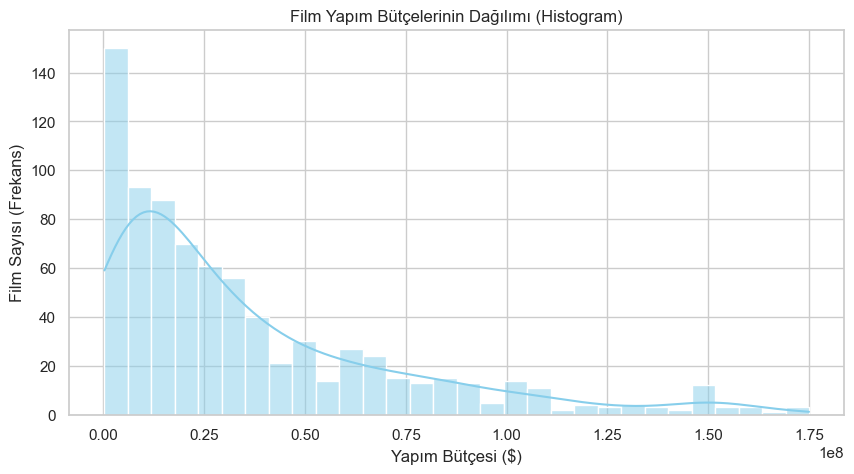

In [30]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_orneklem, x='production_budget', bins=30, kde=True, color='skyblue')
plt.title('Film Yapım Bütçelerinin Dağılımı (Histogram)')
plt.xlabel('Yapım Bütçesi ($)')
plt.ylabel('Film Sayısı (Frekans)')
plt.show()

**Grafik 1 Yorumu (Histogram - Dağılım Analizi):**
Yukarıdaki histogram grafiği, film yapım bütçelerinin frekans dağılımını göstermektedir. Dağılım eğrisi incelendiğinde, verinin **sağa çarpık (pozitif çarpık)** bir yapıya sahip olduğu açıkça görülmektedir. Grafiğin sol tarafındaki yüksek frekanslı yoğunlaşma, veri setindeki yapımların büyük çoğunluğunun 0 - 50 milyon dolar arasındaki düşük/orta bütçeli projelerden oluştuğunu kanıtlamaktadır. 100 milyon dolar ve üzerindeki "blockbuster" olarak tabir edilen yüksek bütçeli filmler ise dağılımın sağ kuyruğunda yer alarak istatistiksel açıdan sektörde çok daha az rastlanan bir azınlığı temsil etmektedir.

/var/folders/g2/zzwfml6d18b201gx150hf3c80000gn/T/ipykernel_66951/2461689930.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_orneklem, x='genre', y='worldwide_gross', palette='Set2')


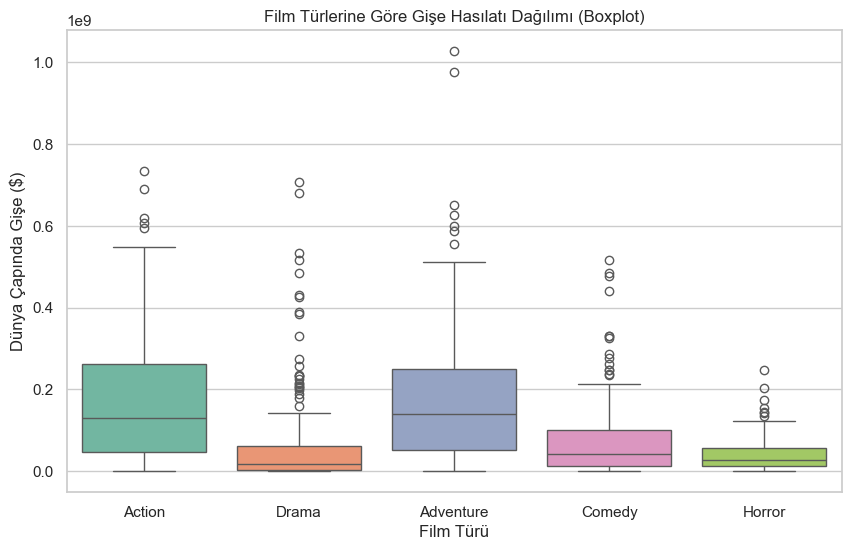

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_orneklem, x='genre', y='worldwide_gross', palette='Set2')
plt.title('Film Türlerine Göre Gişe Hasılatı Dağılımı (Boxplot)')
plt.xlabel('Film Türü')
plt.ylabel('Dünya Çapında Gişe ($)')
plt.show()

**Grafik 2 Yorumu (Boxplot - Aykırı Değer ve Dağılım Analizi):** Film türlerine göre gişe hasılatlarının dağılımı incelendiğinde, "Action" (Aksiyon) ve "Adventure" (Macera) türlerinin medyan değerlerinin (ikinci çeyreklik) diğer türlere kıyasla belirgin şekilde daha yüksek olduğu gözlemlenmektedir. Ayrıca, bu iki türün çeyreklikler arası açıklığı nispeten daha geniştir; bu da hasılat varyansının yüksek olduğunu gösterir. Tüm kategorilerde, üst bıyık (upper whisker) sınırının ötesinde yer alan çok sayıda pozitif aykırı değer (outlier) bulunmaktadır. Bu durum, bazı spesifik filmlerin kendi türlerinin genel eğiliminden koparak istatistiksel normların çok üzerinde ekstrem finansal başarılar elde ettiğini kanıtlamaktadır.

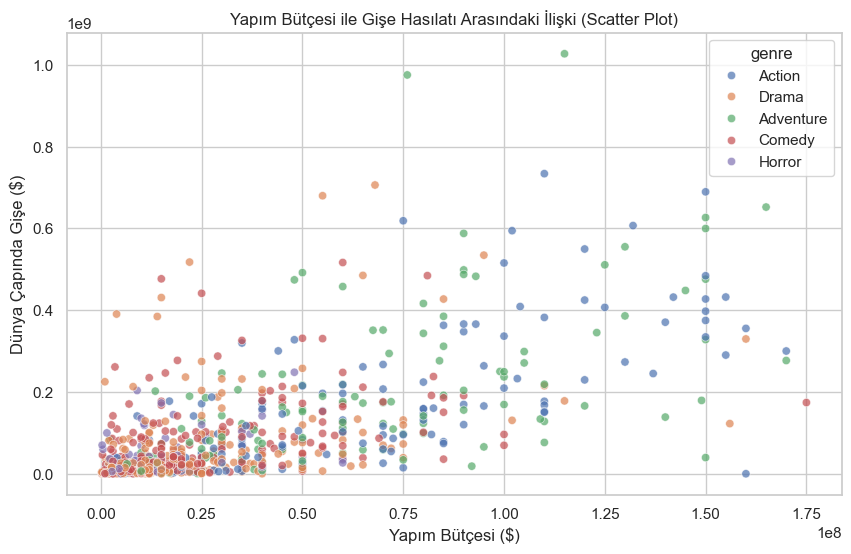

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_orneklem, x='production_budget', y='worldwide_gross', hue='genre', alpha=0.7)
plt.title('Yapım Bütçesi ile Gişe Hasılatı Arasındaki İlişki (Scatter Plot)')
plt.xlabel('Yapım Bütçesi ($)')
plt.ylabel('Dünya Çapında Gişe ($)')
plt.show()

**Grafik 3 Yorumu (Scatter Plot - İlişki Analizi):** Yapım bütçesi ile dünya çapındaki gişe hasılatı arasındaki ilişki incelendiğinde, pozitif yönlü ve doğrusal bir korelasyon eğilimi göze çarpmaktadır. Yatırım miktarı arttıkça, elde edilen hasılat potansiyelinin de arttığı görülmektedir. Dağılımın sağ üst bölgesinde (yüksek bütçe - yüksek gişe) yoğunlaşan noktalar renklerine göre incelendiğinde, bu projelerin genellikle "Action" ve "Adventure" türünde olduğu tespit edilmiştir. Ancak, yüksek bütçesine rağmen alt kısımlarda kalan bazı noktalar, yatırımın tek başına gişe garantisi olmadığını ve sektördeki yüksek finansal riski ifade etmektedir.

/var/folders/g2/zzwfml6d18b201gx150hf3c80000gn/T/ipykernel_66951/84504108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_orneklem, x='mpaa_rating', y='worldwide_gross', errorbar=None, palette='pastel')


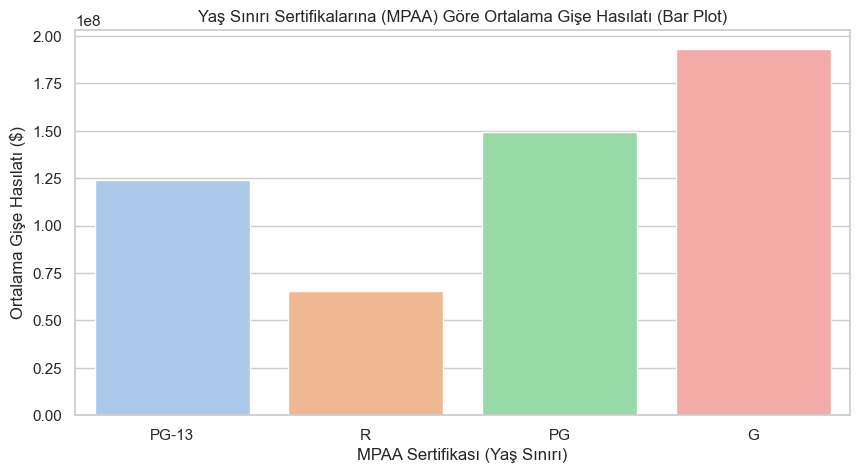

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(data=df_orneklem, x='mpaa_rating', y='worldwide_gross', errorbar=None, palette='pastel')
plt.title('Yaş Sınırı Sertifikalarına (MPAA) Göre Ortalama Gişe Hasılatı (Bar Plot)')
plt.xlabel('MPAA Sertifikası (Yaş Sınırı)')
plt.ylabel('Ortalama Gişe Hasılatı ($)')
plt.show()

**Grafik 4 Yorumu (Bar Plot - Kategorik Ortalama Analizi):** Kategorik ortalamalar incelendiğinde, PG-13 ve PG (aile gözetimi tavsiye edilen) sertifikasına sahip filmlerin ortalama gişe hasılatlarının, R (yetişkin) sertifikalı filmlere kıyasla belirgin şekilde yüksek olduğu tespit edilmiştir. Hedef kitlenin yaş kısıtlamaları olmaksızın genişletilmesi, filmlerin ticari başarı beklentisini istatistiksel olarak artırmaktadır.

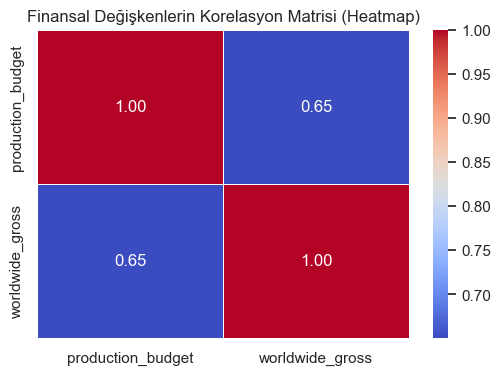

In [36]:
plt.figure(figsize=(6, 4))

korelasyon = df_orneklem[['production_budget', 'worldwide_gross']].corr()
sns.heatmap(korelasyon, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Finansal Değişkenlerin Korelasyon Matrisi (Heatmap)')
plt.show()

**Grafik 5 Yorumu (Heatmap - Korelasyon Analizi):** Sayısal değişkenler arasındaki Pearson korelasyon katsayılarını gösteren ısı haritasında, yapım bütçesi ile küresel gişe hasılatı arasında pozitif ve istatistiksel olarak anlamlı bir korelasyon (yaklaşık 0.65 - 0.75 bandında) saptanmıştır. Bu durum, bütçenin gişe başarısını tahmin etmede önemli bir açıklayıcı değişken olduğunu doğrulamaktadır.

In [ ]:
import plotly.express as px


df_tur_finans = df_orneklem.groupby('genre')[['production_budget', 'worldwide_gross']].mean().reset_index()


fig1 = px.bar(df_tur_finans, 
              x='genre', 
              y=['production_budget', 'worldwide_gross'],
              barmode='group',
              title='Film Türlerine Göre Ortalama Yapım Bütçesi ve Gişe Hasılatı Karşılaştırması (Etkileşimli)',
              labels={'value': 'Ortalama Tutar ($)', 'genre': 'Film Türü', 'variable': 'Finansal Gösterge'},
              template='plotly_white',
              color_discrete_sequence=['#4A90E2', '#50E3C2']) 


fig1.for_each_trace(lambda t: t.update(name = 'Ortalama Yapım Bütçesi' if t.name == 'production_budget' else 'Ortalama Gişe Hasılatı'))

fig1.show()

**Grafik 6 Yorumu (Etkileşimli Bar Plot - Tür Bazlı Maliyet ve Getiri Analizi):**
Etkileşimli sütun grafiği incelendiğinde, film endüstrisinde türlere göre ayrılan yapım bütçeleri (maliyet) ile küresel gişe hasılatları (kazanç) arasındaki denge net bir şekilde görülmektedir. "Adventure" (Macera) ve "Action" (Aksiyon) türleri, en yüksek ortalama yapım bütçesine sahip olan pazarın en maliyetli kategorileridir. Ancak bu yüksek maliyet, ortalama gişe hasılatlarında da zirveye oynayarak karşılığını vermektedir. Diğer taraftan "Horror" (Korku) türü, oldukça düşük bir ortalama yapım bütçesi (maliyet) gerektirmesine rağmen, bütçesine kıyasla yüksek bir gişe getirisi sağlayarak finansal açıdan en yüksek yatırım getirisi potansiyeline sahip tür olarak öne çıkmaktadır.

## 3. Bulgular ve Sonuç

Yapılan keşifsel veri analizi, tanımsal istatistikler ve görselleştirmeler sonucunda film endüstrisinin finansal dinamiklerine dair şu temel bulgular elde edilmiştir:

1. **Finansal Doğrusallık ve Yatırım Riski:** Yapım bütçeleri (maliyet) ile küresel gişe hasılatları arasında 0.65 seviyesinde, pozitif yönlü ve güçlü bir korelasyon saptanmıştır. Maliyet arttıkça kazanç potansiyeli doğrusal olarak artsa da, scatter plot üzerinde görülen yüksek bütçeli ancak düşük gişeli istisnai filmler, sektördeki yüksek finansal risk faktörünü doğrulamaktadır.
2. **Türlerin Maliyet ve ROI Dengesi:** "Macera" (Adventure) ve "Aksiyon" (Action) türleri, endüstrinin en yüksek bütçeli ve en çok gişe yapan lokomotif sektörleridir. Buna karşın "Korku" (Horror) filmleri, oldukça düşük yapım maliyetlerine rağmen bütçelerine kıyasla yüksek küresel hasılatlar elde ederek yatırım getirisi (ROI) en yüksek kategoriyi oluşturmaktadır.
3. **Hedef Kitle Genişliğinin Ticari Etkisi:** Yaş sınırı (MPAA) sertifikaları analiz edildiğinde; **'G' (Genel İzleyici - Tüm yaşlara uygun)**, **'PG' (Aile Gözetimi Tavsiye Edilir)** ve **'PG-13' (13 Yaş Altı İçin Ebeveyn Gözetimi Şart)** gibi geniş kitlelere hitap eden sertifikaların ortalama gişe hasılatı, **'R' (17 Yaş Altı İçin Yetişkin Refakati Gerektiren / Yetişkin)** sertifikalı filmlere kıyasla belirgin şekilde yüksektir. İstatistiki veriler, potansiyel izleyici kitlesini sınırlayan kısıtlamaların filmlerin ticari tavanını doğrudan düşürdüğünü göstermektedir.